# Análisis Cruzado: Stablecoins, Cripto y Sistema de Alertas

Este notebook cruza los datos preprocesados de stablecoins y criptomonedas con el sistema de alertas
(`alertas_sistema_final.csv` y `alertas_criticas_informe.csv`) para responder:

1. ¿Qué variables de stablecoin distinguen a cada nivel de alerta?
2. ¿Cómo se comporta el mercado cripto grande (BTC/ETH/XRP/SOL) en cada nivel de alerta?
3. ¿Coinciden en el tiempo las crisis de peg con movimientos fuertes de BTC?
4. ¿Qué stablecoins concentran más alertas?

> Ajusta las rutas de la celda de carga si tu estructura de carpetas es distinta.

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns

# Nuevas librerías para la conexión a la base de datos y variables de entorno
import os
from dotenv import load_dotenv
from sqlalchemy import create_engine, exc

## 1. Carga de datos

Se buscan los CSV en `../data/clean/` (misma convención que tus notebooks anteriores). Si no los encuentra ahí, prueba en la carpeta actual.

In [ ]:
try:
    # 1. Cargar las variables de entorno desde el archivo .env
    load_dotenv(dotenv_path="../.env") 
    
    db_user = os.getenv("DB_USER")
    db_pass = os.getenv("DB_PASS")
    db_host = os.getenv("DB_HOST")
    db_name = os.getenv("DB_NAME")
    
    # Validar configuración
    if not all([db_user, db_pass, db_host, db_name]):
        raise ValueError("Faltan una o más variables de entorno en el archivo .env")

    # 2. Crear motor de conexión
    connection_string = f"mysql+pymysql://{db_user}:{db_pass}@{db_host}/{db_name}"
    engine = create_engine(connection_string)
    
    print("Conectando a la base de datos para extraer los datasets...")

    # --- DATAFRAME 1: STABLECOINS ---
    query_stable = """
    SELECT h.stablecoin_id, s.nombre_stablecoin AS stablecoin, h.datetime, h.price, 
           h.market_cap, h.peg_deviation, h.supply_change_1d, h.supply_change_7d, h.price_volatility_3d
    FROM preprocesados_historico h
    INNER JOIN stablecoins s ON h.stablecoin_id = s.stablecoin_id;
    """
    df_stable = pd.read_sql(query_stable, con=engine)
    
    # --- DATAFRAME 2: CRIPTOMONEDAS ---
    query_crypto = "SELECT crypto_id, open, high, low, close, volume, datetime FROM crypto_precios;"
    df_crypto = pd.read_sql(query_crypto, con=engine)
    
    # --- DATAFRAME 3: ALERTAS DEL SISTEMA (Corregido sin a.id) ---
    query_sistema = """
    SELECT a.datetime, s.nombre_stablecoin AS stablecoin, a.anomaly_score, 
           a.is_anomaly_stablecoin, a.market_volatility, a.market_stress, a.nivel_alerta
    FROM alertas_sistema a
    INNER JOIN stablecoins s ON a.stablecoin_id = s.stablecoin_id;
    """
    df_sistema = pd.read_sql(query_sistema, con=engine)
    
    # --- DATAFRAME 4: ALERTAS CRÍTICAS (Corregido sin c.id) ---
    query_criticas = """
    SELECT c.datetime, s.nombre_stablecoin AS stablecoin, c.nivel_alerta, 
           c.btc_return, c.eth_return, c.xrp_return, c.sol_return, c.narrativa_alerta
    FROM alertas_criticas c
    INNER JOIN stablecoins s ON c.stablecoin_id = s.stablecoin_id;
    """
    df_criticas = pd.read_sql(query_criticas, con=engine)

    print(f"¡Extracción completada con éxito!")
    print(f" -> Histórico Stablecoins: {len(df_stable)} registros.")
    print(f" -> Histórico Criptomonedas: {len(df_crypto)} registros.")
    print(f" -> Alertas del Sistema: {len(df_sistema)} registros.")
    print(f" -> Alertas Críticas: {len(df_criticas)} registros.")

except ValueError as ve:
    print(f"Error de Configuración: {ve}")
except exc.SQLAlchemyError as se:
    print(f"Error de Base de Datos al mapear el ecosistema de alertas.\nDetalles: {se}")
except Exception as e:
    print(f"Error Inesperado: {e}")

Conectando a la base de datos para extraer los datasets...
¡Extracción completada con éxito!
 -> Histórico Stablecoins: 135423 registros.
 -> Histórico Criptomonedas: 9600 registros.
 -> Alertas del Sistema: 54495 registros.
 -> Alertas Críticas: 225 registros.


In [19]:
for df_temp in [df_stable, df_crypto, df_sistema, df_criticas]:
    if 'datetime' in df_temp.columns:
        df_temp['datetime'] = pd.to_datetime(df_temp['datetime'])

## 2. Preparación: retornos diarios de cripto y unión con alertas

Calculamos el retorno diario (%) de cada criptomoneda grande a partir de su precio de cierre, y lo unimos
(por fecha) a **todas** las filas de `alertas_sistema_final.csv` — no solo a las críticas — para poder
comparar los 3 niveles de alerta entre sí, no solo ver el nivel 2 de forma aislada.

In [20]:
# 1. Unificar primero las alertas del sistema y las alertas críticas
df_alertas = pd.concat([df_sistema, df_criticas], ignore_index=True)

# Asegurar formatos de fecha correctos para evitar conflictos en los cruces
df_alertas["datetime"] = pd.to_datetime(df_alertas["datetime"])
df_stable["datetime"] = pd.to_datetime(df_stable["datetime"])
df_crypto["datetime"] = pd.to_datetime(df_crypto["datetime"])

# 2. EN LUGAR DE CONCAT: Hacemos un MERGE entre las alertas y las métricas de stablecoins
# Cruzamos por fecha Y por moneda para que cada alerta tenga sus métricas correspondientes
df_alertas_con_metricas = df_alertas.merge(df_stable, on=["datetime", "stablecoin"], how="inner")

# 3. Limpiar duplicados del mercado cripto antes de pivotar
df_crypto_clean = df_crypto.drop_duplicates(subset=['datetime', 'crypto_id'], keep='first')
df_crypto_pivot = df_crypto_clean.pivot(index="datetime", columns="crypto_id", values="close").sort_index()

# 4. Calcular los retornos diarios del mercado cripto
df_returns = df_crypto_pivot.pct_change().rename(columns=lambda c: f"{c}_return")

# 5. Hacer el cruce final con los retornos del mercado usando la fecha como índice
df_merged = df_alertas_con_metricas.merge(df_returns, left_on="datetime", right_index=True, how="left")

# 6. Definir y ordenar las categorías de las alertas
ORDER = ["0_normal", "1_VIGILANCIA_STABLECOIN", "2_ALERTA_MERCADO"]
df_merged["nivel_alerta"] = pd.Categorical(df_merged["nivel_alerta"], categories=ORDER, ordered=True)

print(f"Dataset cruzado correctamente. Registros listos para graficar: {len(df_merged)}")
df_merged.head()

Dataset cruzado correctamente. Registros listos para graficar: 492480


,datetime,stablecoin,anomaly_score,is_anomaly_stablecoin,market_volatility,market_stress,nivel_alerta,btc_return,eth_return,xrp_return,...,price,market_cap,peg_deviation,supply_change_1d,supply_change_7d,price_volatility_3d,bitcoin_return,ethereum_return,ripple_return,solana_return
0,2024-05-01,BUSD,0.221191,0.0,0.061847,1.0,0_normal,NaN,NaN,NaN,...,0.996697,70355422.0,0.003303,-0.002202,-0.006188,0.001654,0.041799,0.036396,0.042024,0.127168
1,2024-05-01,BUSD,0.221191,0.0,0.061847,1.0,0_normal,NaN,NaN,NaN,...,0.996697,70355422.0,0.003303,-0.002202,-0.006188,0.001654,0.041799,0.036396,0.042024,0.127168
2,2024-05-01,BUSD,0.221191,0.0,0.061847,1.0,0_normal,NaN,NaN,NaN,...,0.996697,70355422.0,0.003303,-0.002202,-0.006188,0.001654,0.041799,0.036396,0.042024,0.127168
3,2024-05-01,BUSD,0.221191,0.0,0.061847,1.0,0_normal,NaN,NaN,NaN,...,0.996697,70355422.0,0.003303,-0.002202,-0.006188,0.001654,0.041799,0.036396,0.042024,0.127168
4,2024-05-01,BUSD,0.221191,0.0,0.061847,1.0,0_normal,NaN,NaN,NaN,...,0.996697,70355422.0,0.003303,-0.002202,-0.006188,0.001654,0.041799,0.036396,0.042024,0.127168


## 3. Bloque 1 — Nivel de alerta vs. variables propias de la stablecoin

Categórica (`nivel_alerta`) vs. numéricas (`peg_deviation`, `price_volatility_3d`, `anomaly_score`, `market_volatility`).
`peg_deviation` y `price_volatility_3d` van en escala log porque su distribución está muy concentrada cerca de cero
con colas largas.

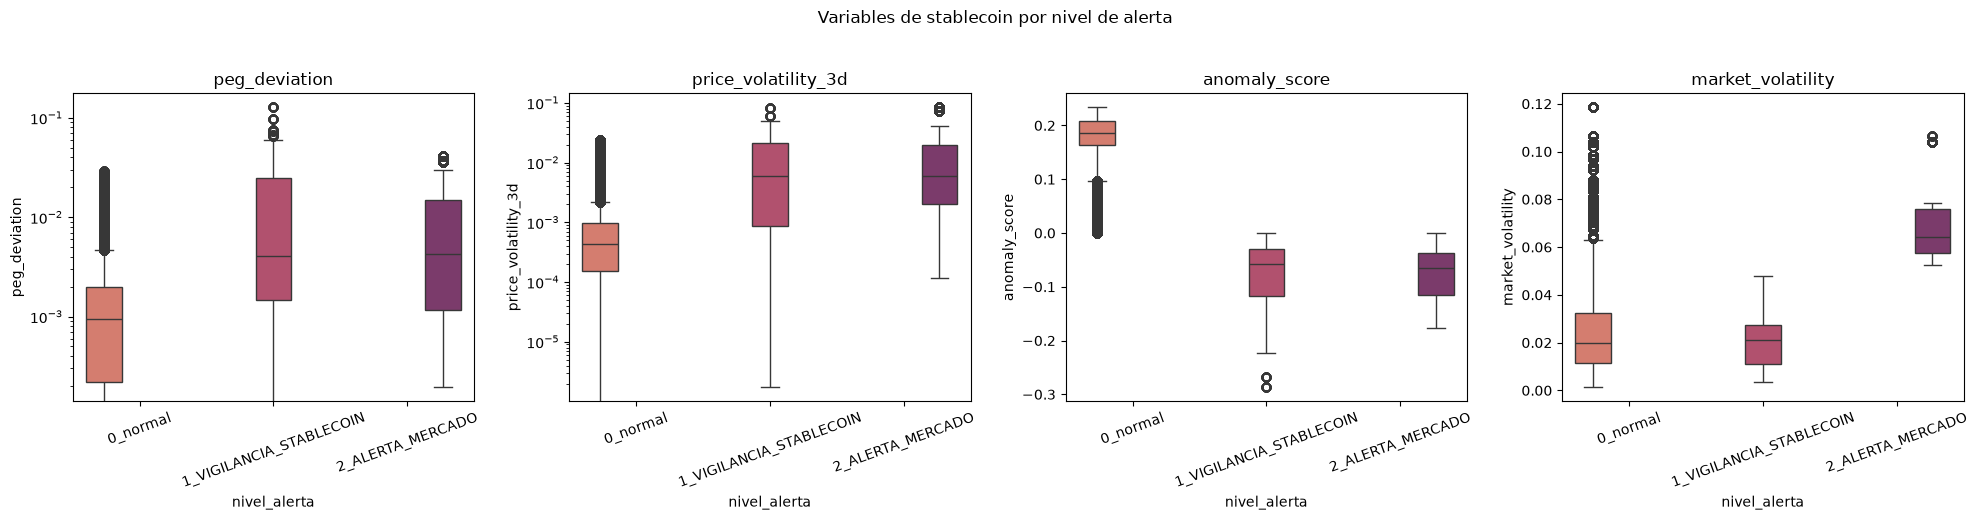

,peg_deviation,price_volatility_3d,anomaly_score,market_volatility
nivel_alerta,,,,
0_normal,0.001685,0.000996,0.179180,0.024858
1_VIGILANCIA_STABLECOIN,0.014920,0.012662,-0.080031,0.021184
2_ALERTA_MERCADO,0.010565,0.014799,-0.075055,0.069358


In [21]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
metrics1 = ["peg_deviation", "price_volatility_3d", "anomaly_score", "market_volatility"]
for ax, m in zip(axes, metrics1):
    sns.boxplot(data=df_merged, x="nivel_alerta", y=m, order=ORDER, hue="nivel_alerta",
                palette="flare", legend=False, ax=ax)
    if m in ("peg_deviation", "price_volatility_3d"):
        ax.set_yscale("log")
    ax.set_title(m)
    ax.tick_params(axis="x", rotation=20)
plt.suptitle("Variables de stablecoin por nivel de alerta", y=1.03)
plt.tight_layout()
plt.show()

df_merged.groupby("nivel_alerta", observed=True)[metrics1].mean()

## 4. Bloque 2 — Nivel de alerta vs. retornos del mercado cripto

Aquí vemos si los niveles de alerta coinciden con caídas (o subidas) fuertes de BTC/ETH/XRP/SOL ese mismo día.
La línea gris en 0 ayuda a ver si la mediana/caja se desplaza hacia territorio negativo (caída) en los niveles
más altos de alerta.

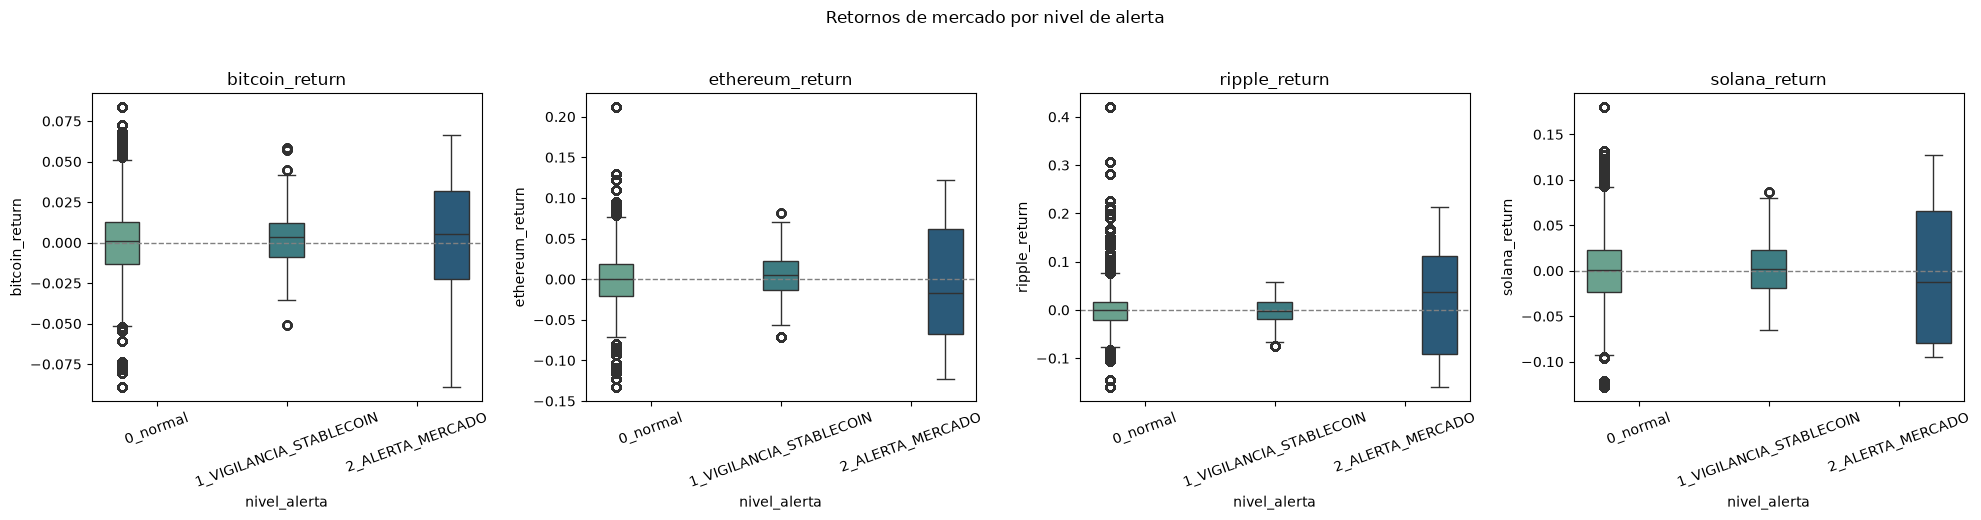

bitcoin_return           ethereum_return            \
                                  mean       std            mean       std   
nivel_alerta                                                                 
0_normal                      0.000370  0.022506       -0.000164  0.033539   
1_VIGILANCIA_STABLECOIN       0.003024  0.019143        0.003676  0.027611   
2_ALERTA_MERCADO              0.002177  0.039669       -0.006596  0.068475   

                        ripple_return           solana_return            
                                 mean       std          mean       std  
nivel_alerta                                                             
0_normal                     0.001319  0.043563      0.000274  0.039146  
1_VIGILANCIA_STABLECOIN     -0.002965  0.028037      0.001223  0.033061  
2_ALERTA_MERCADO             0.013776  0.118607      0.004543  0.079419

In [22]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
metrics2 = ["bitcoin_return", "ethereum_return", "ripple_return", "solana_return"]
for ax, m in zip(axes, metrics2):
    sns.boxplot(data=df_merged, x="nivel_alerta", y=m, order=ORDER, hue="nivel_alerta",
                palette="crest", legend=False, ax=ax)
    ax.axhline(0, color="gray", ls="--", lw=1)
    ax.set_title(m)
    ax.tick_params(axis="x", rotation=20)
plt.suptitle("Retornos de mercado por nivel de alerta", y=1.03)
plt.tight_layout()
plt.show()

df_merged.groupby("nivel_alerta", observed=True)[metrics2].agg(["mean", "std"])

## 5. Bloque 3 — Serie temporal cruzada

Superponemos la desviación media diaria del peg (todas las stablecoins) con el precio de BTC, marcando con
líneas verticales los días de alerta nivel 1 (naranja) y nivel 2 (rojo). Sirve para ver visualmente si las
crisis de peg preceden, coinciden o siguen a movimientos fuertes de BTC.

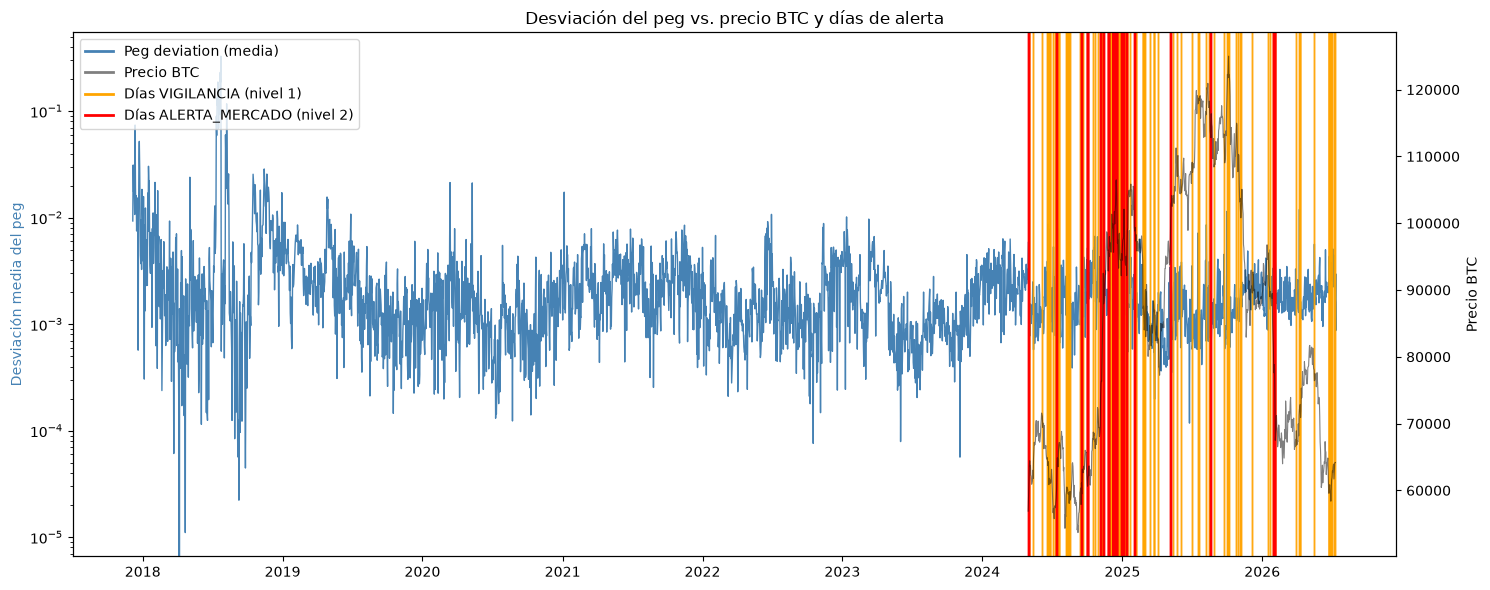

In [23]:
peg_daily = df_stable.groupby("datetime")["peg_deviation"].mean()
btc = df_crypto_pivot["bitcoin"]
alert_days_1 = df_alertas.loc[df_alertas["nivel_alerta"] == "1_VIGILANCIA_STABLECOIN", "datetime"]
alert_days_2 = df_alertas.loc[df_alertas["nivel_alerta"] == "2_ALERTA_MERCADO", "datetime"]

fig, ax1 = plt.subplots(figsize=(15, 6))
ax1.plot(peg_daily.index, peg_daily.values, color="steelblue", lw=1)
ax1.set_ylabel("Desviación media del peg", color="steelblue")
ax1.set_yscale("log")
for d in alert_days_1:
    ax1.axvline(d, color="orange", alpha=0.25, lw=1)
for d in alert_days_2:
    ax1.axvline(d, color="red", alpha=0.5, lw=1.5)

ax2 = ax1.twinx()
ax2.plot(btc.index, btc.values, color="black", lw=0.8, alpha=0.5)
ax2.set_ylabel("Precio BTC", color="black")

custom_lines = [Line2D([0], [0], color="steelblue", lw=2),
                Line2D([0], [0], color="black", lw=2, alpha=0.5),
                Line2D([0], [0], color="orange", lw=2),
                Line2D([0], [0], color="red", lw=2)]
ax1.legend(custom_lines,
           ["Peg deviation (media)", "Precio BTC", "Días VIGILANCIA (nivel 1)", "Días ALERTA_MERCADO (nivel 2)"],
           loc="upper left")
plt.title("Desviación del peg vs. precio BTC y días de alerta")
plt.tight_layout()
plt.show()

## 6. Bloque 4 — Stablecoin vs. nivel de alerta (tabla de contingencia)

Categórica vs. categórica: ¿qué stablecoins concentran más alertas de vigilancia (1) o de mercado (2)?

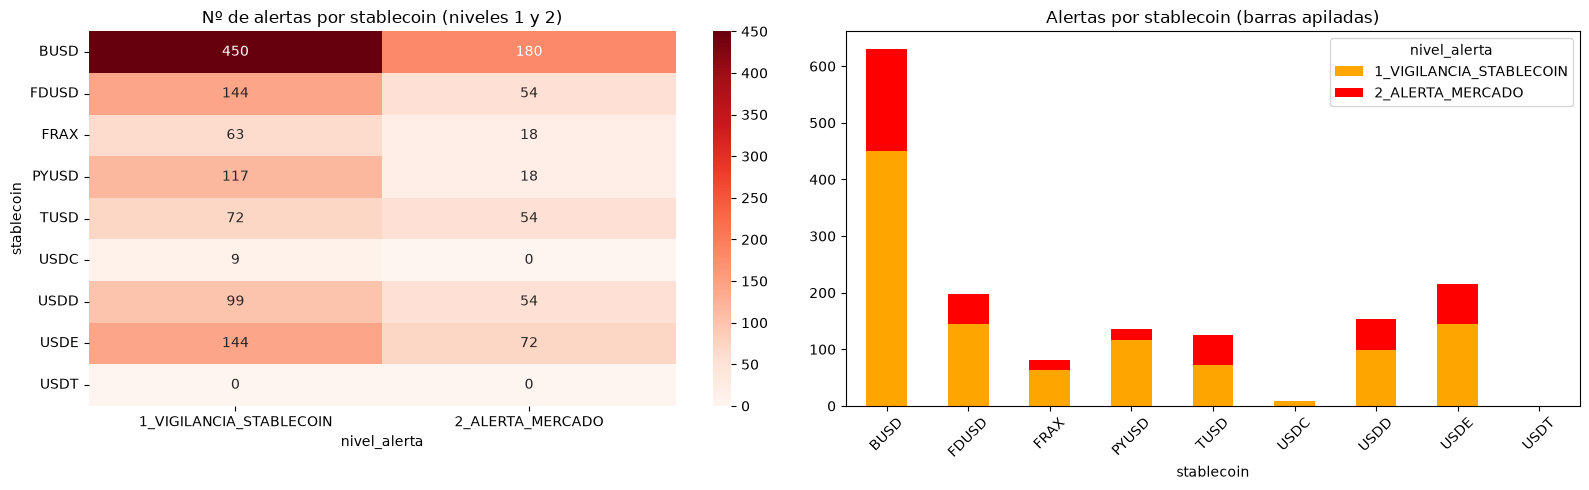

In [24]:
ct = pd.crosstab(df_alertas["stablecoin"], df_alertas["nivel_alerta"])
ct_alertas = ct[["1_VIGILANCIA_STABLECOIN", "2_ALERTA_MERCADO"]]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.heatmap(ct_alertas, annot=True, fmt="d", cmap="Reds", ax=axes[0])
axes[0].set_title("Nº de alertas por stablecoin (niveles 1 y 2)")

ct_alertas.plot(kind="bar", stacked=True, ax=axes[1], color=["orange", "red"])
axes[1].set_title("Alertas por stablecoin (barras apiladas)")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## 7. Notas

- `alertas_criticas_informe.csv` ya trae, para cada evento de nivel 2, una `narrativa_alerta` en texto
  generada automáticamente — útil para un informe ejecutivo, pero no se usa directamente en el análisis
  numérico de este notebook (son 20 filas, ya cubiertas por el cruce de arriba con más contexto).
- Si quieres profundizar en un evento concreto, filtra `df_criticas` por fecha o por stablecoin y cruza
  con `df_stable`/`df_crypto` en una ventana de +/- unos días alrededor del evento.